# Partition distribution & mergeability — optimized DP2 builds

Analysis of the partitioning of three size-optimized `hats-import` builds of DP2 object
data (partial-sky test regions under `/sdf/data/rubin/user/olynn/mem_size_dp2/`), built to
a **target maximum partition size of 1 GB in-memory**. **Gaia DR3** is the benchmark
catalog throughout. The heavy machinery lives in [`partition_stats.py`](partition_stats.py).

These are the **2026-07-17 rebuilds**, made after fixing the size estimator (booleans
were priced at 1 byte instead of bit-packed 1/8 byte — see
[`size_estimation.md`](size_estimation.md) §4). The July 9 builds capped at ~87% of
budget; the merge audit of those builds predicted that a correct estimator would
produce exactly **259 / 109 / 266** partitions — which is precisely what the rebuild
produced.

| catalog | partitions | rows | sky fraction | orders | arrow total | max partition |
|---|---|---|---|---|---|---|
| optimized_0 | 259 | 10.4M | 0.23% | 4–8 | 113.5 GB | 971 MB |
| optimized_1 | 109 | 12.6M | 1.11% | 3–7 | 40.1 GB | 987 MB |
| optimized_2 | 266 | 54.8M | 0.99% | 4–6 | 125.6 GB | 996 MB |

### Three notions of "partition size"

Data inflates twice on the way from disk to RAM — decompression (~1.4–1.5× here), then
decoding of parquet's dictionary/RLE pages into plain arrow buffers (another ~1.5–2×):

| measure | function | cost |
|---|---|---|
| on-disk compressed bytes | `partition_sizes` | one `os.stat` per file |
| rows + parquet-uncompressed bytes | `partition_frame` | one `_metadata` read |
| **exact arrow in-memory bytes** (`Table.nbytes`) | `partition_arrow_mb` | full read of every file (cached) |

The 1 GB budget is an *in-memory* budget, so mergeability must be judged with
`partition_arrow_mb` — the cheap proxies understate RAM by 1.5–3× and wildly overstate
how much could be merged (on the July 9 builds they suggested 40–67% over-splitting when
the true number was 4–10%). Scans are cached in `.partition_cache/` next to this
notebook, so everything below runs in seconds.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import partition_stats as ps

ps.quiet()  # silence third-party log spam + benign hats plot warning
%matplotlib inline
plt.rcParams.update({"font.size": 14, "axes.titlesize": 16, "axes.labelsize": 14})

MEM_ROOT = "/sdf/data/rubin/user/olynn/mem_size_dp2"
CATALOGS = {f"optimized_{i}": f"{MEM_ROOT}/optimized_{i}/optimized_{i}" for i in range(3)}
GAIA = "/sdf/data/rubin/cosmicdata/lsdb/gaia_dr3/gaia"  # benchmark

MERGE_THRESH_MB = 1000.0  # build target: max partition size, in-memory

# Partition size distributions (on disk)

Histograms of on-disk compressed parquet bytes per partition. Sizes come from stat-ing
each partition's deterministic path, so `_metadata`, skymaps and thumbnails are excluded.

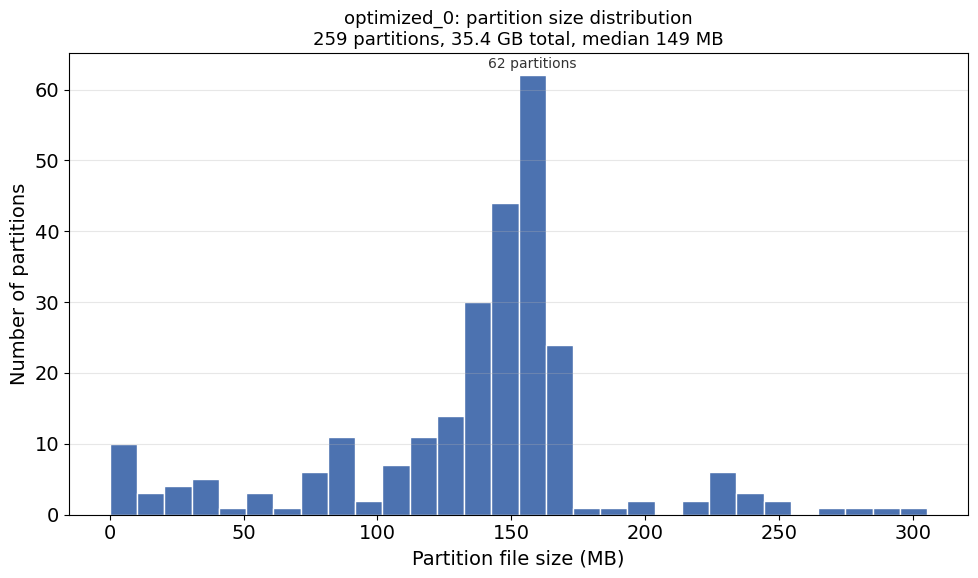

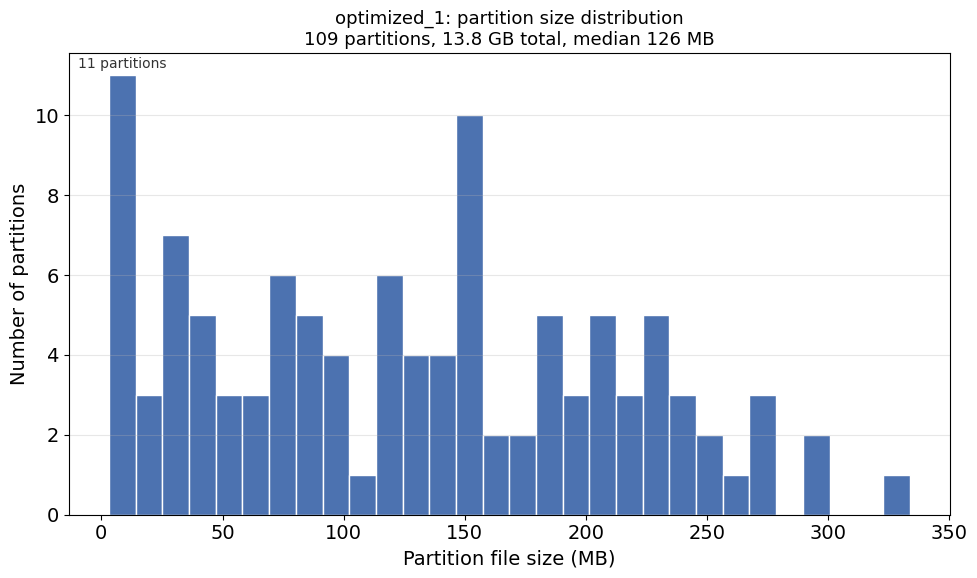

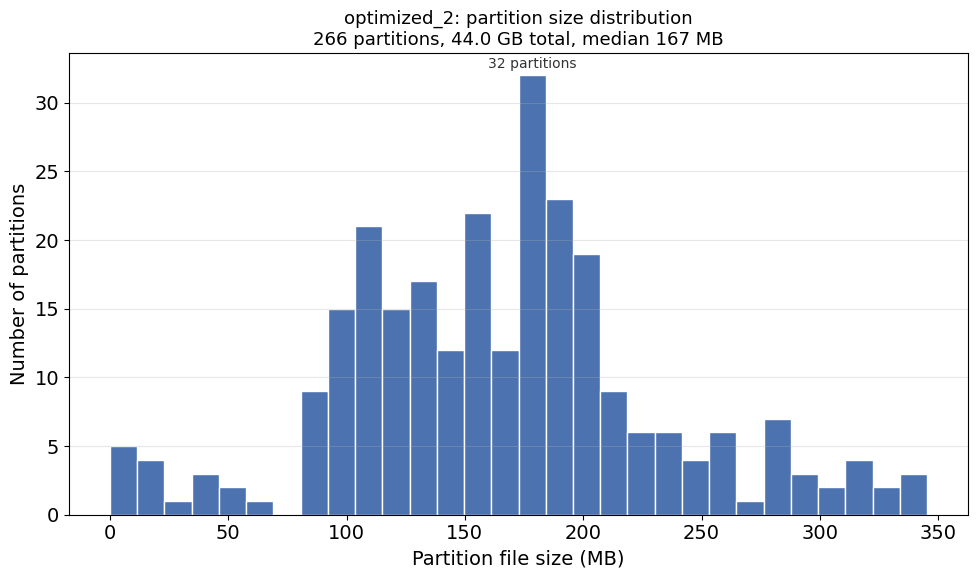

In [2]:
for name, path in CATALOGS.items():
    ps.plot_partition_hist(name, path)

# Where partition-size extremes sit on the sky

The 20 largest and 20 smallest partitions (by on-disk bytes) over each footprint. The
footprints cover ≲1% of the sky, so the scatter uses RA/Dec axes centred on the footprint
(RA re-centred via the circular mean, so optimized_2 — which straddles RA = 0° — stays
contiguous). Grey points are the remaining partitions.

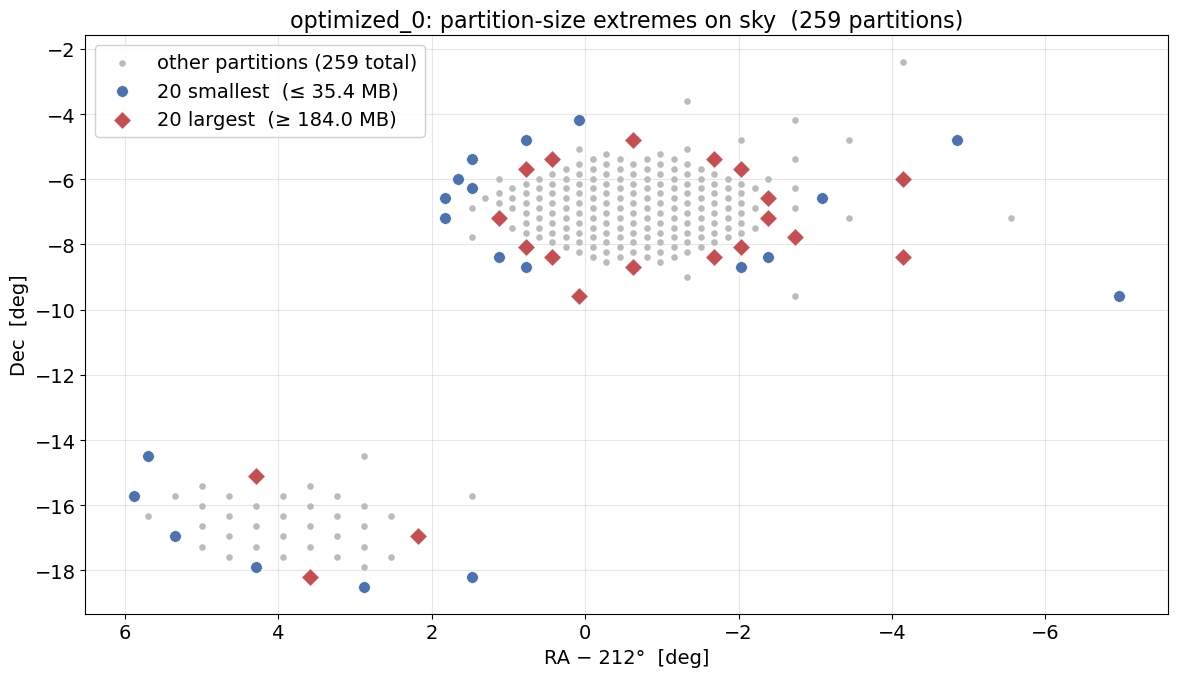

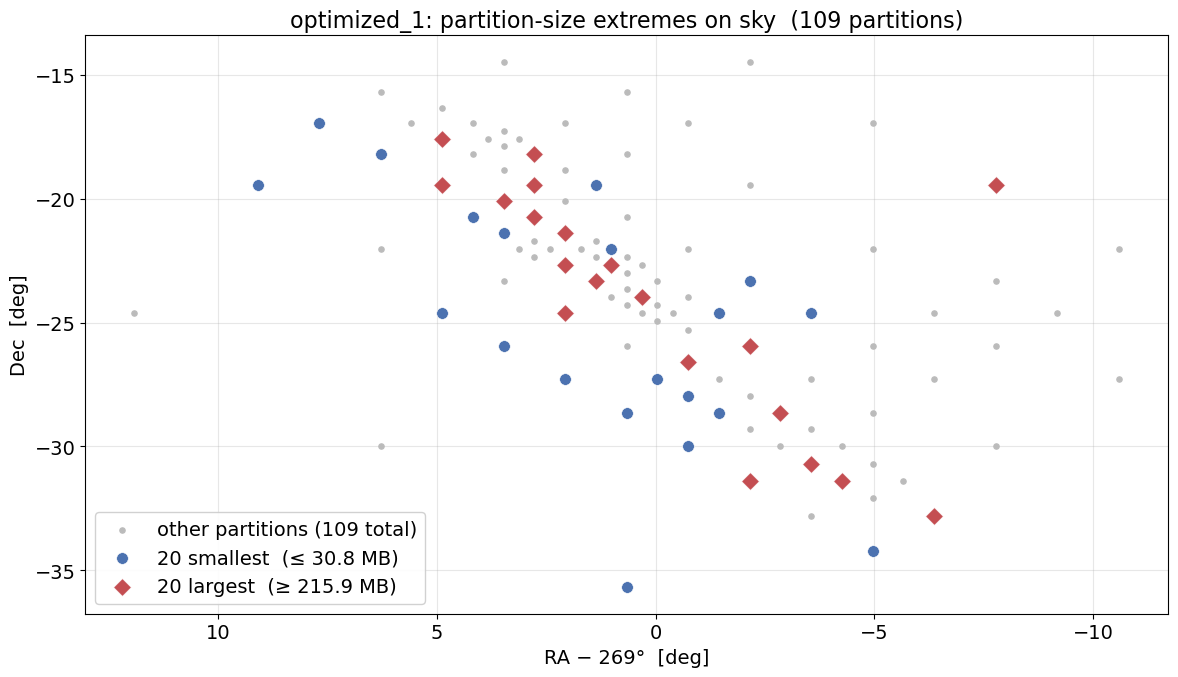

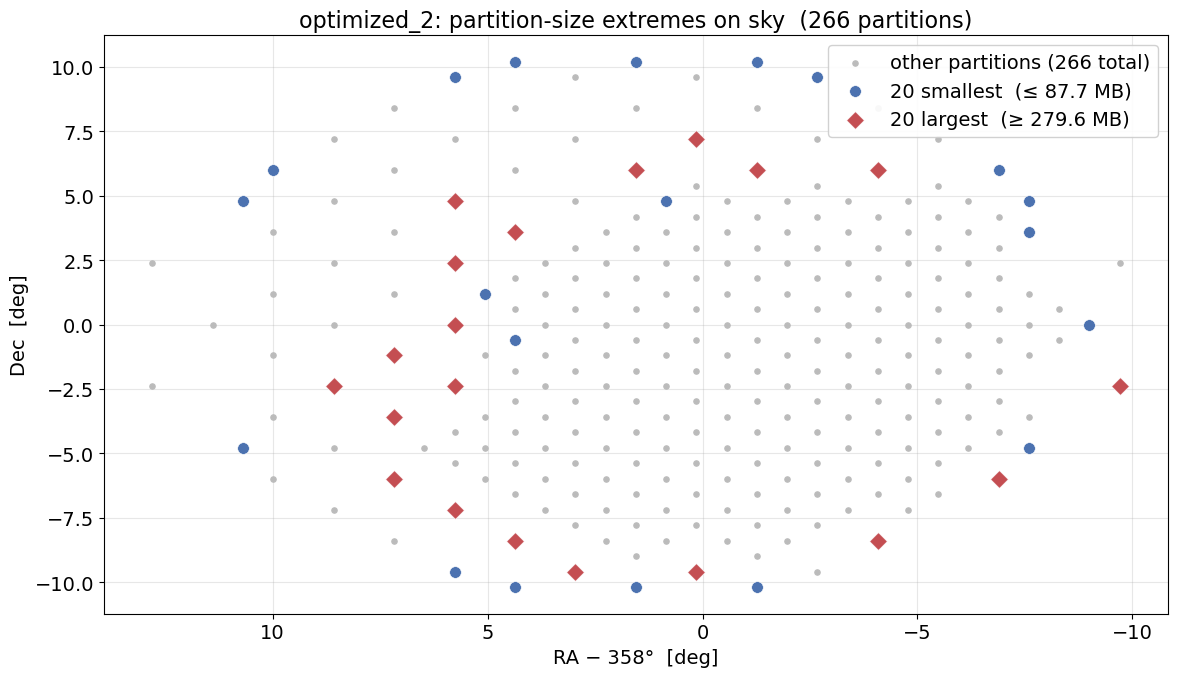

In [3]:
for name, path in CATALOGS.items():
    ps.plot_extremes_on_sky(name, path)

# Native partition maps (tile renderer) + Gaia comparison

Real HEALPix tiles coloured by per-partition **row count**, via `hats`'s
`plot_healpix_map` (int64 `ipix`/`depth` avoids the uint64-specific hats#703 crash).
Gaia is full-sky (Mollweide); the optimized footprints auto-zoom (TAN projection).

Note the builds' `hats_max_rows = 1,000,000` cap never binds — no partition exceeds
~645k rows; the 1 GB in-memory size target is the active constraint.

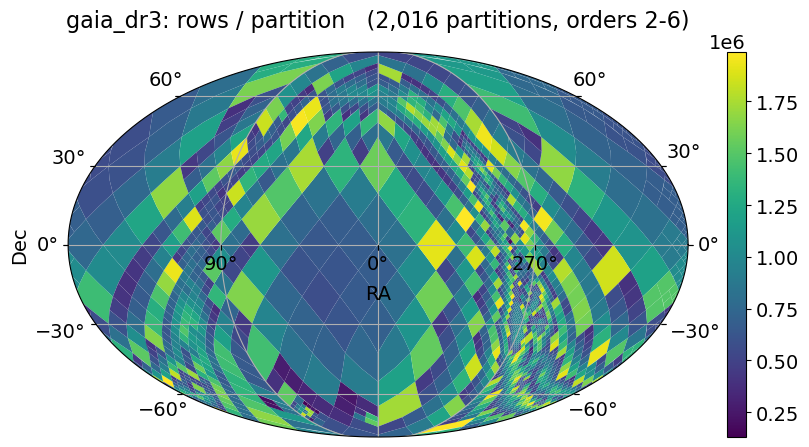

In [4]:
# Gaia DR3 benchmark — full sky (~7 s cold, instant cached).
_ = ps.plot_partition_map("gaia_dr3", GAIA, by="rows")

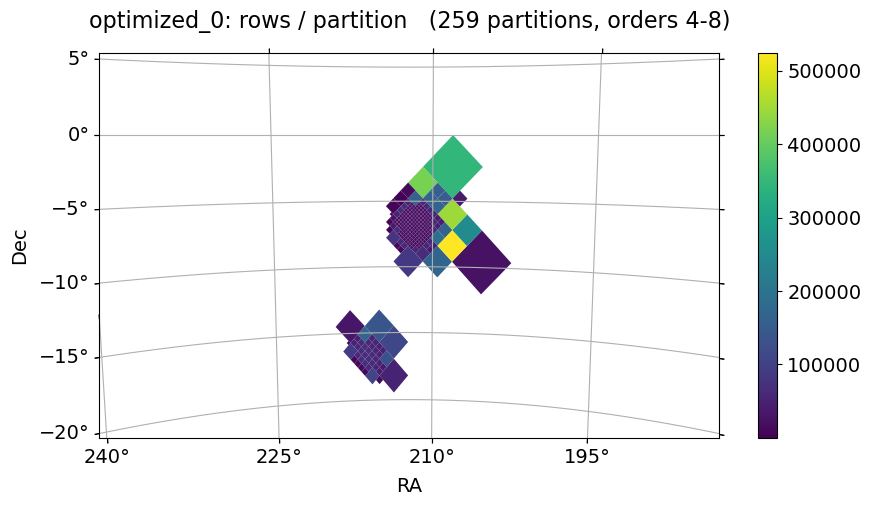

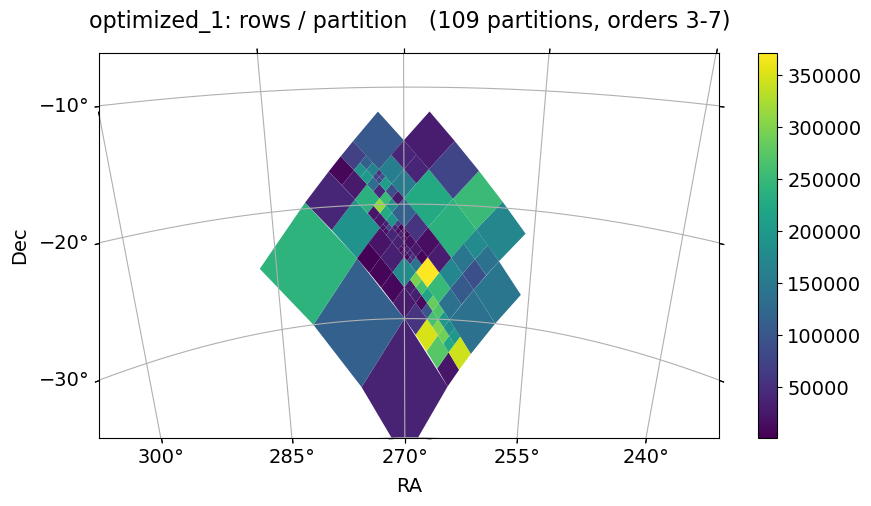

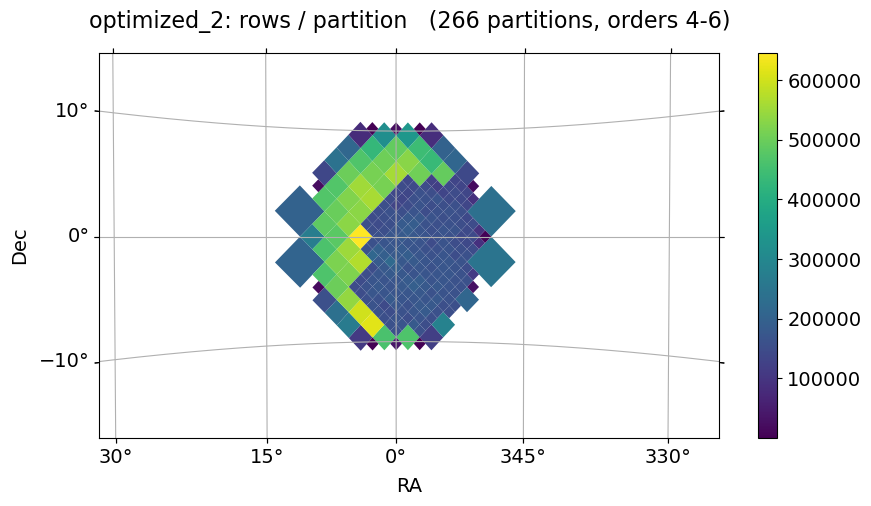

In [5]:
for name, path in CATALOGS.items():
    _ = ps.plot_partition_map(name, path, by="rows")

# Gaia partition-size distribution (vs optimized builds)

On-disk bytes per partition for Gaia DR3, and PDF overlays against the optimized builds.
Per catalog: dotted line = median, dashed line = max/4 — the size a partition would have
after one more HEALPix split (4 children), where an upper-edge dropoff is expected.

Headline: Gaia partitions are chunkier — median **335 MB** across **2,016** partitions,
vs **126–167 MB** medians for the optimized builds. The optimized builds' ~305–345 MB
on-disk ceiling is the compressed shadow of their 1 GB in-memory target (~3× compression
from arrow buffers to parquet files on this data).

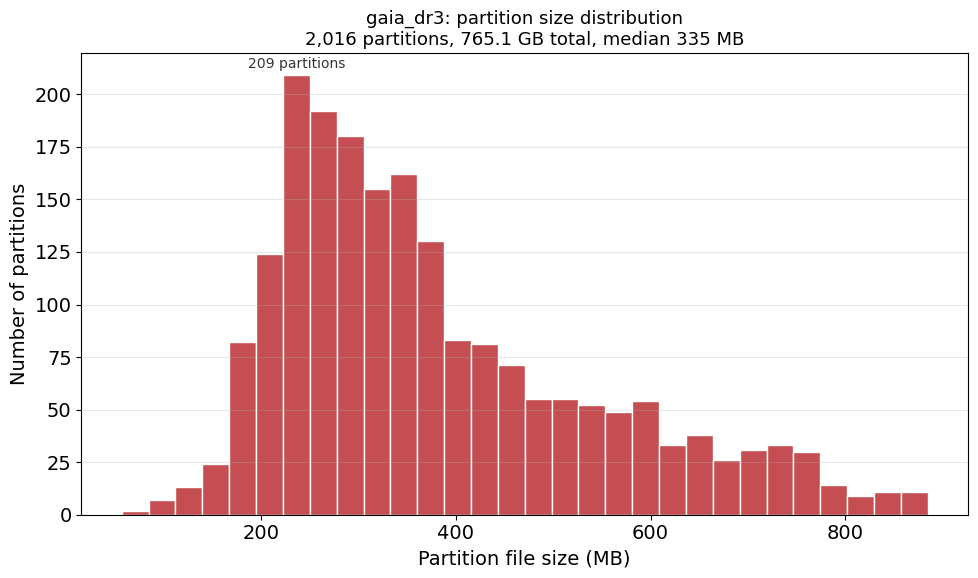

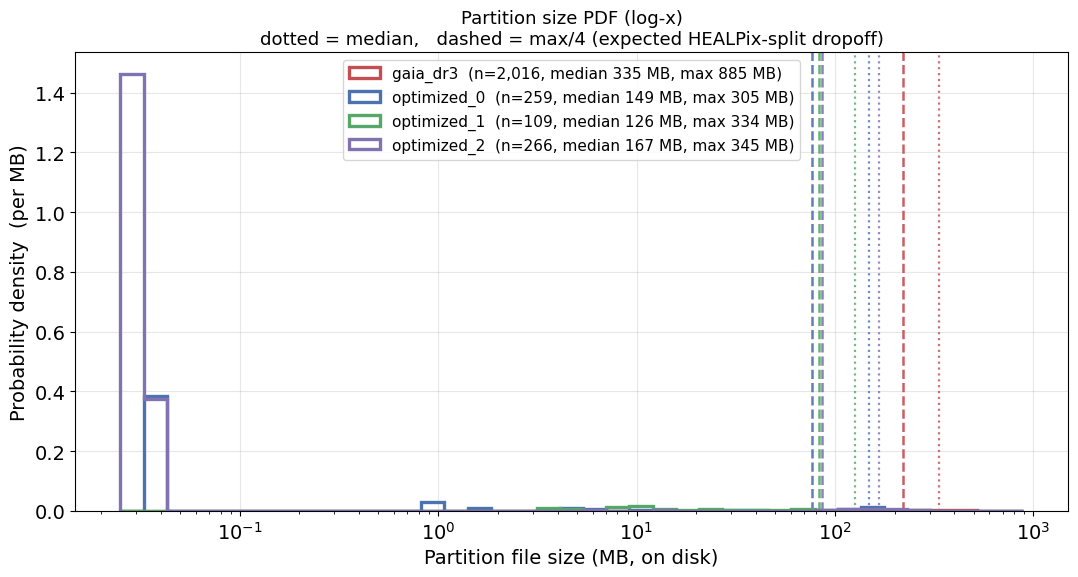

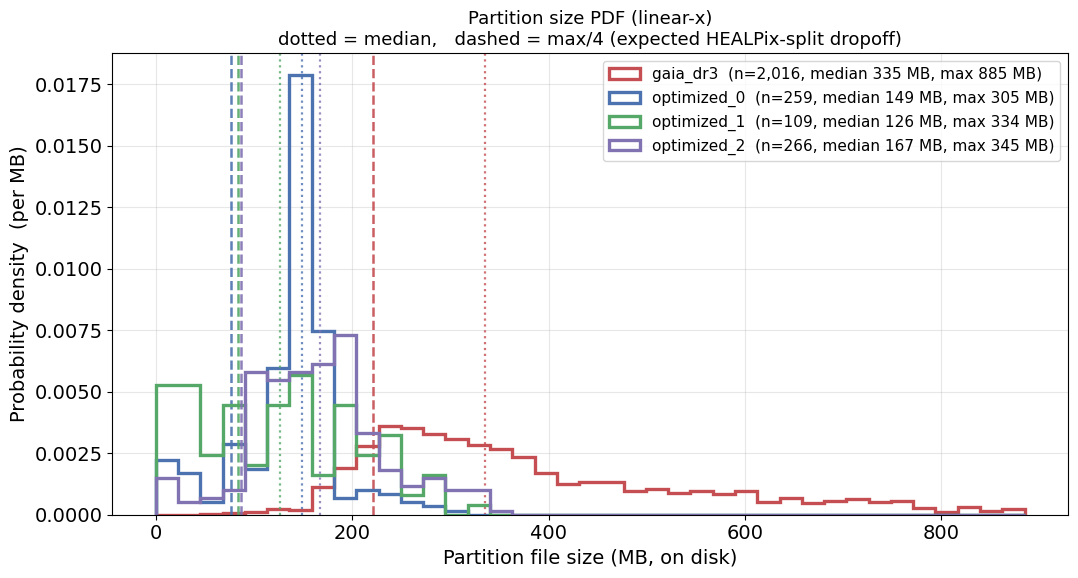

catalog                  n      total     median       mean        max      max/4
gaia_dr3             2,016   765.1 GB     335 MB     379 MB     885 MB     221 MB
optimized_0            259    35.4 GB     149 MB     137 MB     305 MB      76 MB
optimized_1            109    13.8 GB     126 MB     127 MB     334 MB      83 MB
optimized_2            266    44.0 GB     167 MB     165 MB     345 MB      86 MB


In [6]:
overlay = {"gaia_dr3": ps.ondisk_mb(GAIA)}
overlay.update({name: ps.ondisk_mb(path) for name, path in CATALOGS.items()})
colors = {"gaia_dr3": "#C44E52", "optimized_0": "#4C72B0",
          "optimized_1": "#55A868", "optimized_2": "#8172B2"}

ps.plot_partition_hist("gaia_dr3", GAIA, color=colors["gaia_dr3"])
ps.plot_size_pdf_overlay(overlay, colors, "log")
ps.plot_size_pdf_overlay(overlay, colors, "linear")
ps.print_size_table(overlay)

# Partition size split by HEALPix order

If partitioning were a fixed-order grid, each step to a finer order would cut pixel area
(and partition size) by 4×, so per-order size histograms would sit ~4× apart. A
size-targeted builder instead picks a finer order exactly where the sky is denser,
cancelling the ÷4 area step with ×4 density — flat per-order medians are its signature
(Gaia shows this clearly at ~270–395 MB across orders 2–6). The printed consecutive
median ratios make the comparison explicit: 4.0× = fixed grid, ~1× = size-targeted.

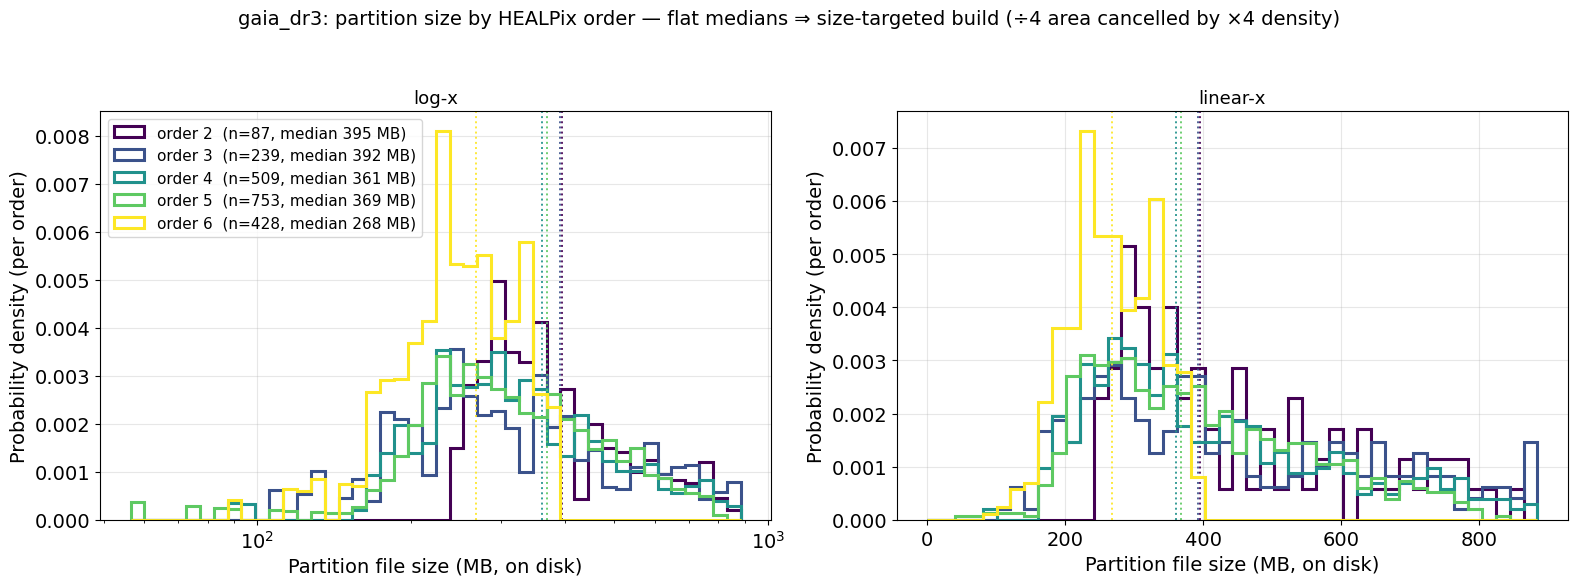

gaia_dr3: consecutive median ratios (order o / o+1) = 1.0x, 1.1x, 1.0x, 1.4x   (4.0x = fixed-grid expectation)


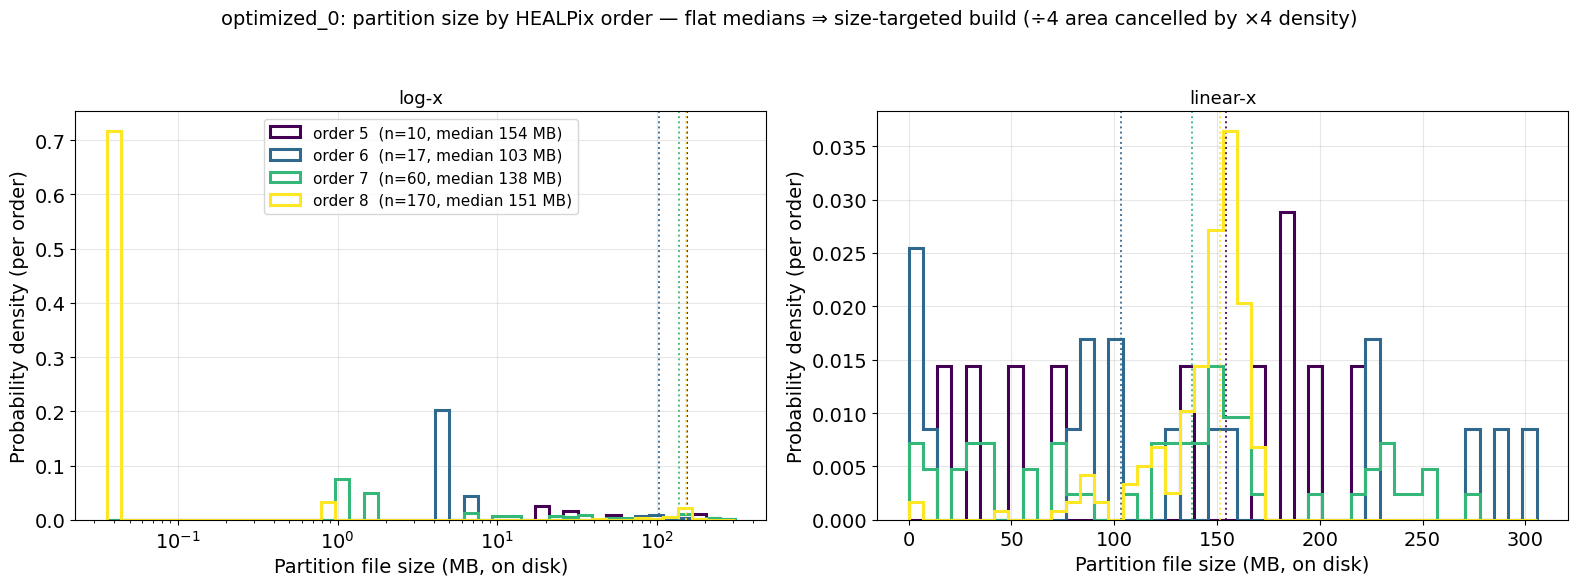

optimized_0: consecutive median ratios (order o / o+1) = 1.5x, 0.7x, 0.9x   (4.0x = fixed-grid expectation)


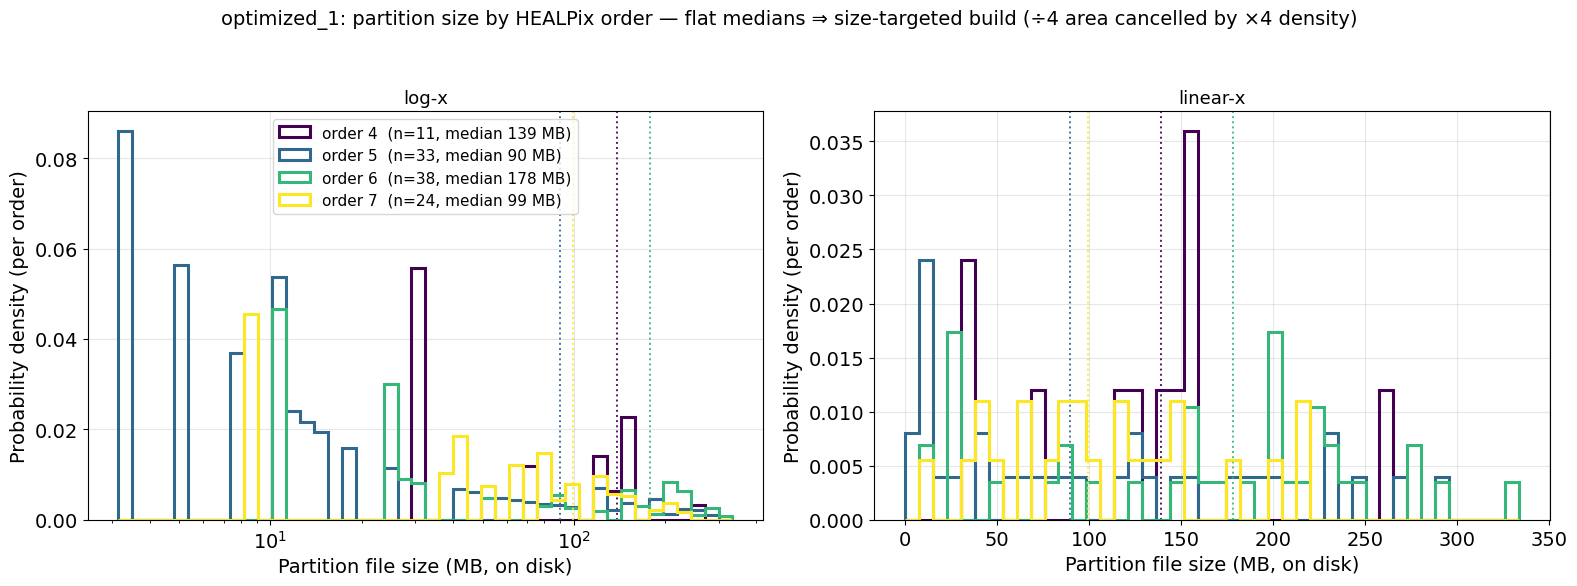

optimized_1: consecutive median ratios (order o / o+1) = 1.5x, 0.5x, 1.8x   (4.0x = fixed-grid expectation)


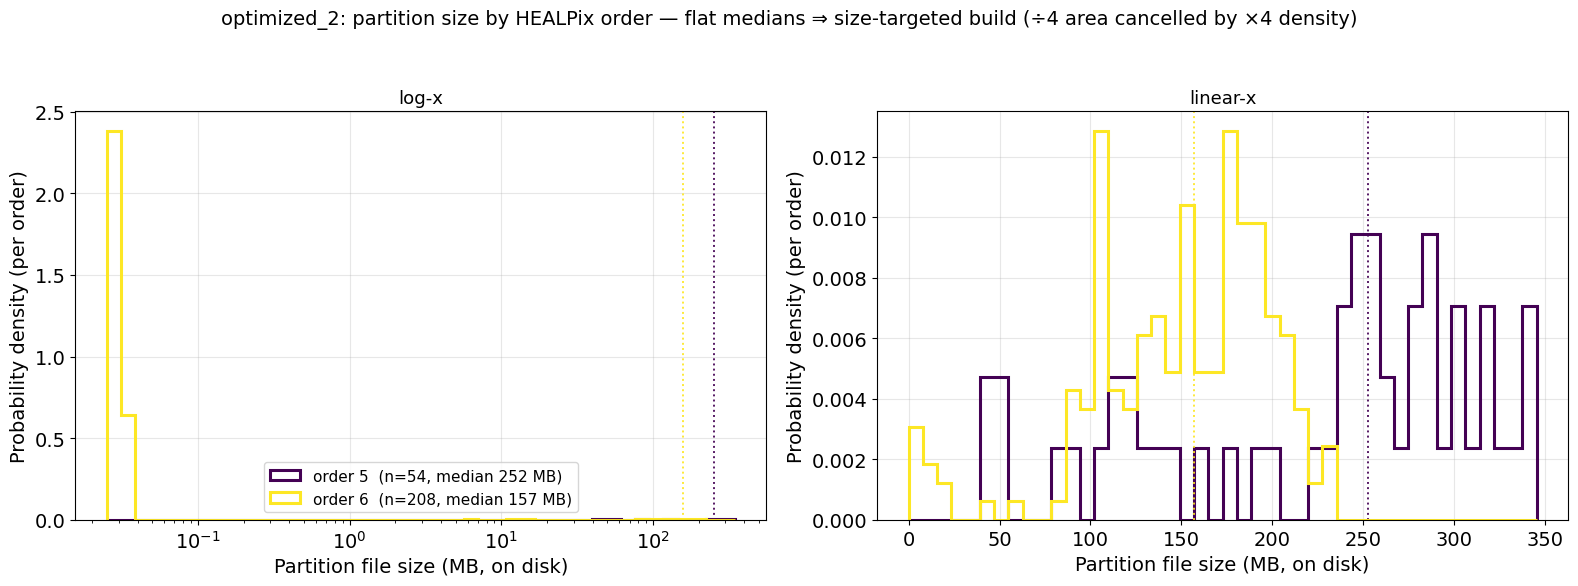

optimized_2: consecutive median ratios (order o / o+1) = 1.6x   (4.0x = fixed-grid expectation)


In [7]:
ps.plot_size_by_order("gaia_dr3", GAIA)
for name, path in CATALOGS.items():
    ps.plot_size_by_order(name, path)

# Over-split partitions: what could be aggregated to a coarser order?

Using HEALPix nesting (a pixel's parent one order coarser is `npix // 4`, NESTED),
`ps.rollup` accumulates every partition into its ancestor subtrees and
`ps.maximal_merge_groups` finds the **coarsest** subtree whose combined size stays under
the **1 GB in-memory** build target. Each such subtree would hold >1 partition that could
collapse into a single coarser one without exceeding the budget.

Sizes are **exact in-memory sizes** (`Table.nbytes` via `partition_arrow_mb`); summing
children is the right merge estimate since concatenating arrow tables is essentially
exact. Using the cheap proxies here badly overstates mergeability (see intro).

For the rebuilt catalogs the answer is **zero merge groups in all three** — no subtree
of sibling partitions could be collapsed without exceeding 1 GB, i.e. the partitioning
is provably as coarse as the budget allows. (The July 9 builds, made with the biased
estimator, showed 4.4% / 7.6% / 9.5% here.)

optimized_0: 259 partitions, threshold 1000 MB (arrow in-memory)
  0 maximal merge groups -> eliminate 0 partitions (0.0%) -> new count 259

  top 15 candidates (parent order/npix : #partitions -> 1, merged size):


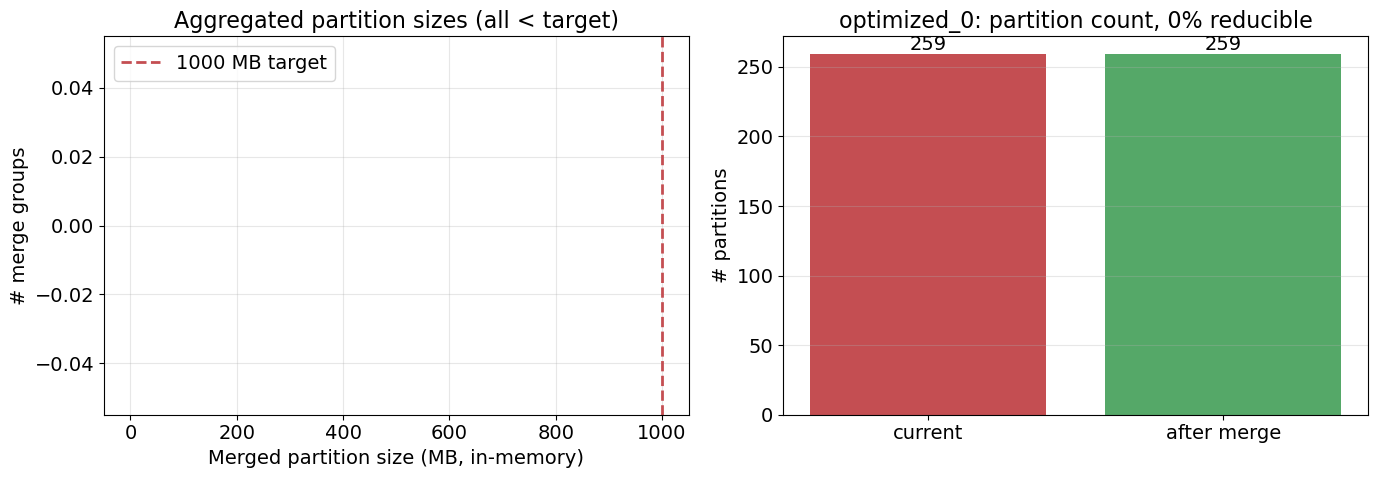

optimized_1: 109 partitions, threshold 1000 MB (arrow in-memory)
  0 maximal merge groups -> eliminate 0 partitions (0.0%) -> new count 109

  top 15 candidates (parent order/npix : #partitions -> 1, merged size):


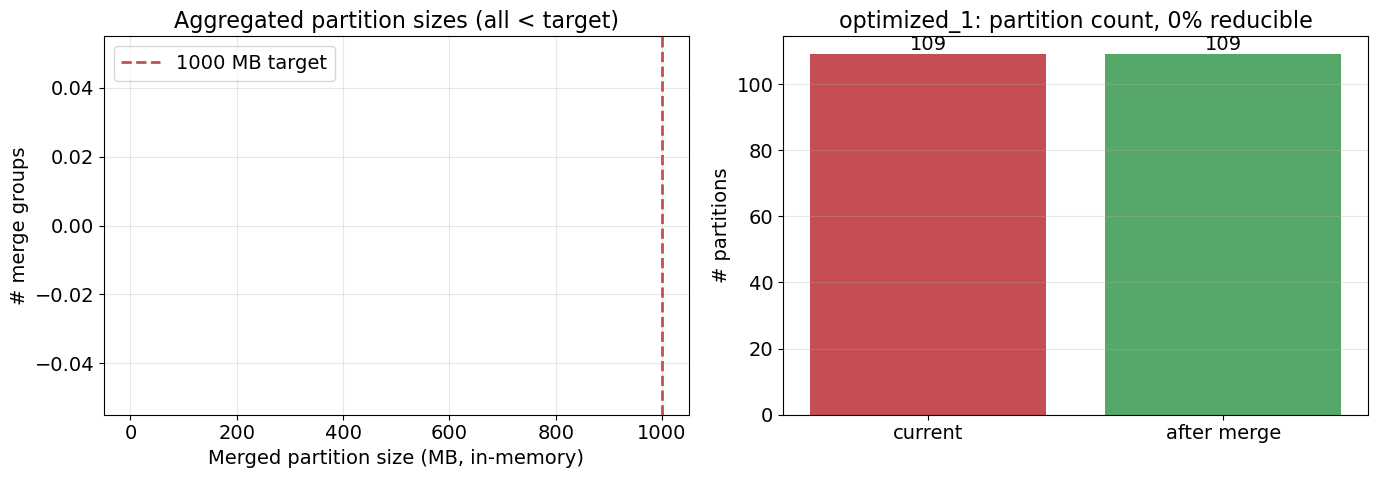

optimized_2: 266 partitions, threshold 1000 MB (arrow in-memory)
  0 maximal merge groups -> eliminate 0 partitions (0.0%) -> new count 266

  top 15 candidates (parent order/npix : #partitions -> 1, merged size):


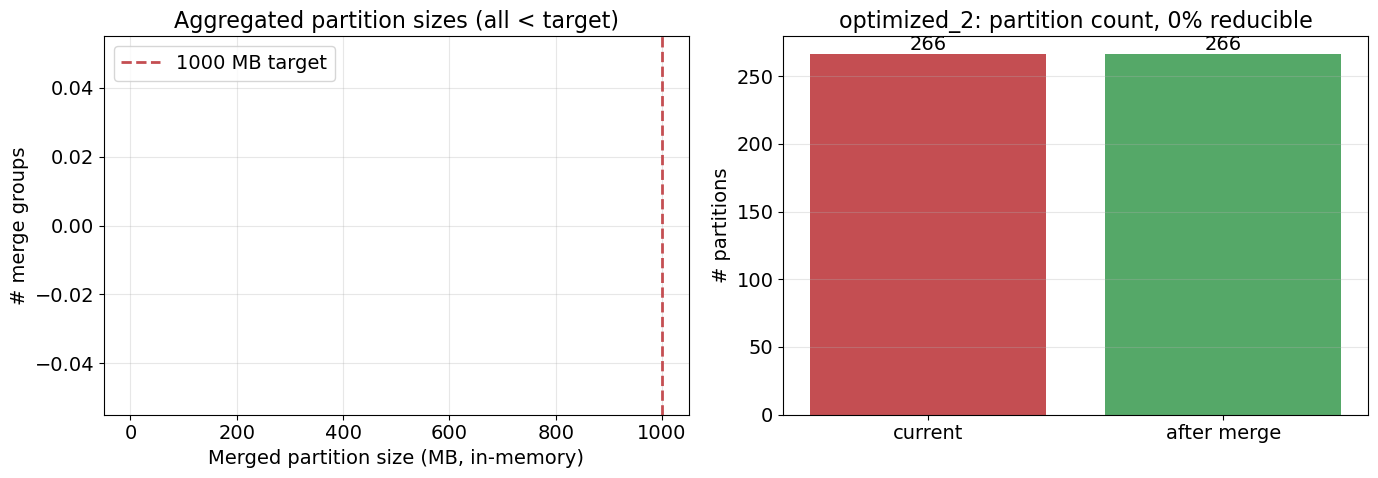

In [8]:
for name, path in CATALOGS.items():
    _ = ps.merge_candidates(name, path, thresh_mb=MERGE_THRESH_MB)

## Aggregation depth — can you merge more than once?

The roll-up already goes to **convergence**: it picks the *coarsest* ancestor still under
the threshold, and since subtree size grows monotonically up the tree, re-running finds
nothing new. "Merging twice" shows up as groups whose collapse spans **≥2 HEALPix order
levels** (depth = deepest child order − parent order).

With zero merge groups in the rebuilt catalogs, the before/after distributions below are
identical — the green "after" curve sits exactly on the red "before" curve, which is the
visual signature of a fully-aggregated build. (On the July 9 builds these figures showed
the small-partition tail emptying into a band pressed against the 1 GB line.)

optimized_0: aggregation depth (HEALPix levels collapsed):
   -> 0 groups aggregate >=2 levels ('twice or more')

   deepest examples (parent order/npix : depth, #parts -> 1, size):


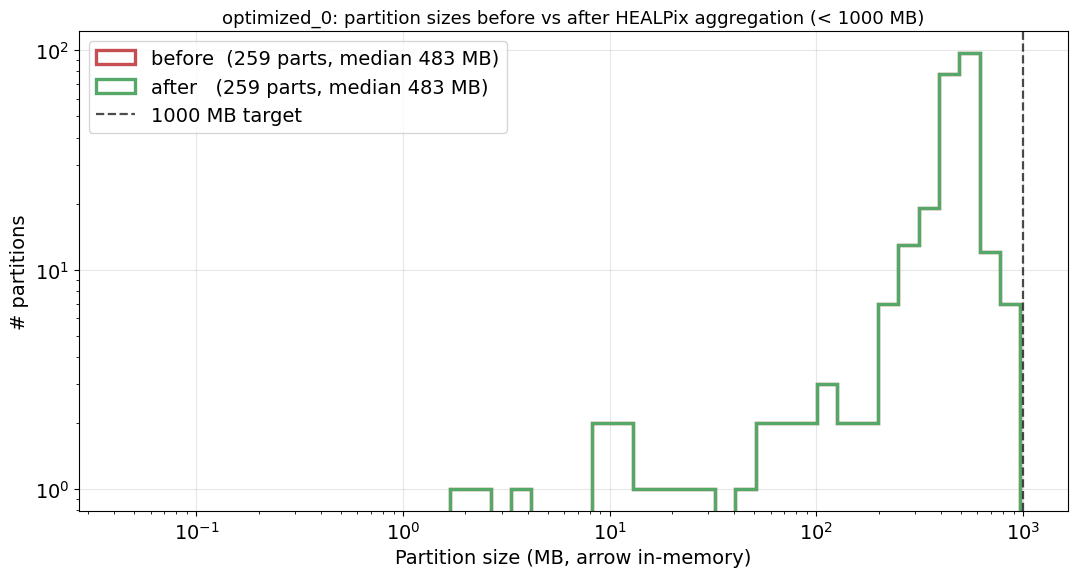

optimized_1: aggregation depth (HEALPix levels collapsed):
   -> 0 groups aggregate >=2 levels ('twice or more')

   deepest examples (parent order/npix : depth, #parts -> 1, size):


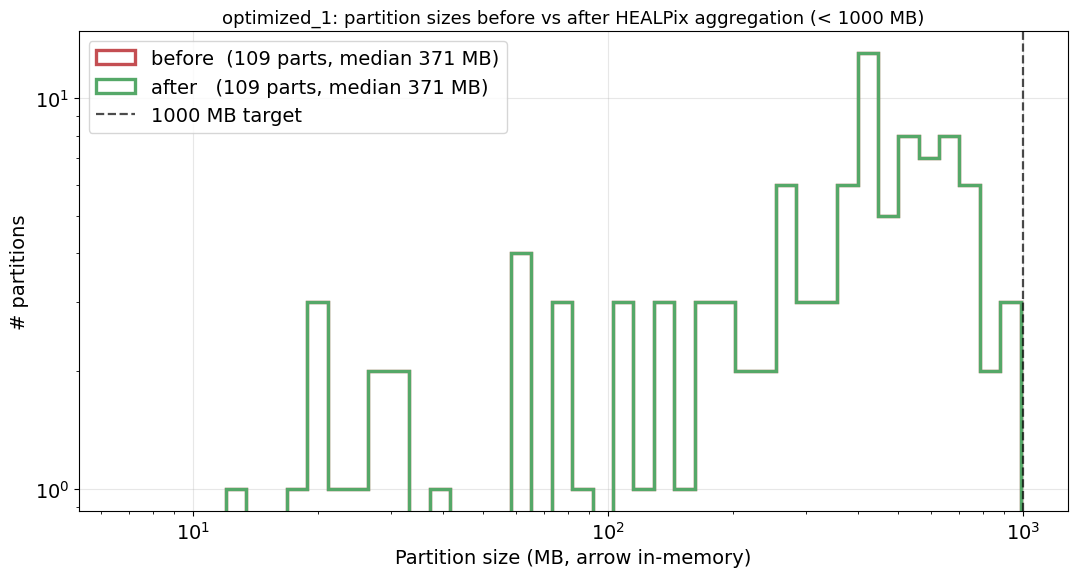

optimized_2: aggregation depth (HEALPix levels collapsed):
   -> 0 groups aggregate >=2 levels ('twice or more')

   deepest examples (parent order/npix : depth, #parts -> 1, size):


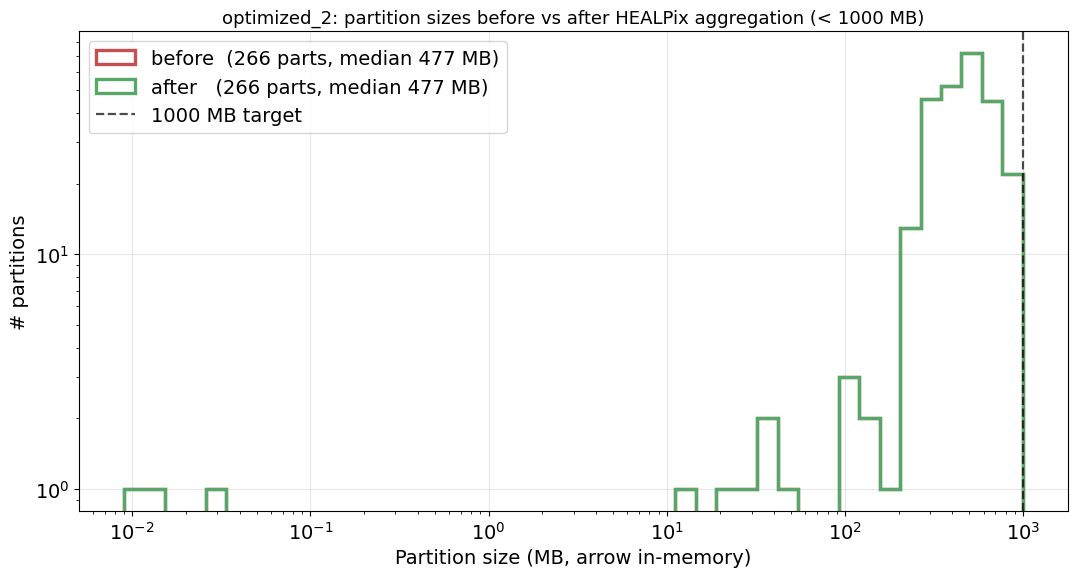

In [9]:
for name, path in CATALOGS.items():
    _ = ps.aggregation_report(name, path, thresh_mb=MERGE_THRESH_MB)

## One merge example, drawn as HEALPix tiles

When a catalog has mergeable parents, this cell draws one: every partition under the
parent as its true HEALPix tile, coloured/labelled by exact in-memory MB, inside the red
parent-pixel outline — a concrete picture of what "aggregate to a coarser order" means.

The rebuilt catalogs have **nothing to draw**: the auto-picker finds no merge groups and
returns `None` with a message. The cell is kept as a standing check — if a future build
regresses, the example will reappear here.

In [10]:
example_parent = ps.plot_merge_example("optimized_0", CATALOGS["optimized_0"],
                                       thresh_mb=MERGE_THRESH_MB)

optimized_0: no merge groups under 1000 MB - nothing to draw.


### Where a merge example would sit on the partition map

With `example_parent = None` there is no region to mark, so this renders the plain
optimized_0 row-count map. When a build has merge groups, the chosen parent pixel is
overlaid here as a red tile for context.

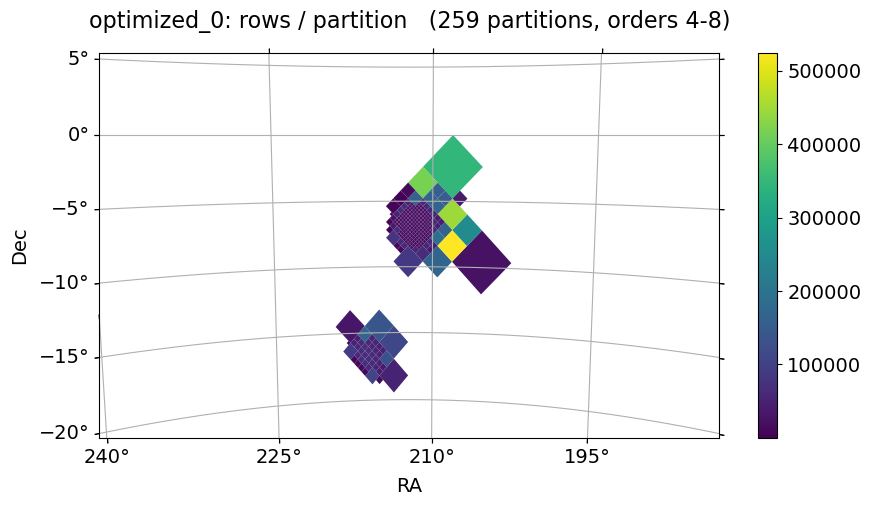

In [11]:
_ = ps.plot_partition_map("optimized_0", CATALOGS["optimized_0"],
                          by="rows", mark=example_parent)

# Conclusions

- The estimator fix worked, and the merge audit validated it end-to-end: the July 9
  audit predicted a correct estimator would yield **259 / 109 / 266** partitions, and
  the 2026-07-17 rebuilds produced exactly those counts.
- All three builds **use the 1 GB in-memory budget fully**: max partitions are
  **971 / 987 / 996 MB** arrow (the July 9 builds capped at 809/835/869 MB — ~87% of
  budget — because booleans were priced at 8× their bit-packed size).
- **Zero over-splitting remains**: at the 1000 MB threshold there are no merge groups in
  any catalog — no set of sibling partitions could be collapsed coarser without
  exceeding the budget. The partitioning is optimal for this threshold.
- The `hats_max_rows = 1M` cap still never binds (max ~645k rows); the memory target is
  the active constraint.
- Judge mergeability only with exact arrow sizes (`Table.nbytes`): disk bytes understate
  RAM ~3×, parquet-uncompressed metadata ~1.5–2.3×. The proxy-based audits of the July 9
  builds suggested 40–67% over-splitting when the truth was 4–10%; details in
  [`size_estimation.md`](size_estimation.md).